# PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA) - DATASET TITANIC


## 1. Định nghĩa vấn đề

- **Mô tả:**
    - Train data: 891 dòng, 12 cột
    - Test data: 418 dòng, 11 cột
- **Dữ liệu vào:**
    - `PassengerId`: id
    - `Pclass`: hạng vé (1, 2, 3)
    - `Name`: tên hành khách
    - `Sex`: giới tính
    - `Age`: tuổi
    - `SibSp`: số anh chị em họ đi cùng
    - `Parch`: số phụ huynh hoặc con cái đi cùng
    - `Ticket`: số vé
    - `Fare`: giá vé
    - `Cabin`: số cabin
    - `Embarked`: cảng lên tàu (C: , Q: , S: )
- **Kết quả:**
    - Dữ liệu cột Survived dạng binary (0, 1)
    - 1: Sống sót, 0: Tử vong

## 2. Chuẩn bị vấn đề

### 2.1. Khai báo thư viện

In [22]:
# %load_ext autoreload
%reload_ext autoreload
%autoreload 2

# Import các thư viện cần thiết
import pandas as pd
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython import display
from scipy import stats
from scipy.stats import chi2_contingency, pearsonr, spearmanr

sys.path.append(os.path.abspath('..'))
from src import visualization
# Thiết lập
warnings.filterwarnings('ignore')
data_dir = '../../data/titanic/'
print("Đã import thành công các thư viện cần thiết!")

Đã import thành công các thư viện cần thiết!


### 2.2. Nạp dữ liệu

In [23]:
train_df = pd.read_csv(f'{data_dir}train.csv')
test_df = pd.read_csv(f'{data_dir}test.csv')

## 3. Phân tích dữ liệu

### 3.1. Thống kê mô tả

#### (1) **Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu
+ Thông tin chung về dữ liệu

In [45]:
print("="*15, "Train", "="*15)
print(f"- Shape: {train_df.shape}")
print(f"- Types:\n{train_df.dtypes}")
print("- Header(5):")
display.display(train_df.head())
print(f"- Info:\n{train_df.info()}")

=============== Train ===============
- Shape: (891, 12)
- Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
- Header(5):


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
- Info:
None


In [49]:
print("="*15, "Test", "="*15)
print(f"- Shape: {test_df.shape}")
print(f"- Types:\n{test_df.dtypes}")
print("- Header(5):")
display.display(test_df.head())
print(f"- Info:\n{test_df.info()}")

=============== Test ===============
- Shape: (418, 11)
- Types:
PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
- Header(5):


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
- Info:
None


#### (2) **Kiểm tra tính toàn vẹn của dữ liệu**

In [50]:
print("-"*10, "Missing Values", "-"*10)
def missing_values_info(df):
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    missing_df = pd.DataFrame({
        'Cột': missing_data.index,
        'Số lượng thiếu': missing_data.values,
        'Tỷ lệ % thiếu': missing_percent.values
    })
    missing_df = missing_df[missing_df['Số lượng thiếu'] > 0].sort_values('Số lượng thiếu', ascending=False)
    return missing_df

print("\n- Train Data:")
display.display(missing_values_info(train_df))

print("\n- Test Data:")
display.display(missing_values_info(test_df))

print("-"*10, "Duplicate Rows", "-"*10)
print(f"Train: {train_df.duplicated().sum()}")
print(f"Test: {test_df.duplicated().sum()}")

---------- Missing Values ----------

- Train Data:


,Cột,Số lượng thiếu,Tỷ lệ % thiếu
10,Cabin,687,77.104377
5,Age,177,19.865320
11,Embarked,2,0.224467



- Test Data:


,Cột,Số lượng thiếu,Tỷ lệ % thiếu
9,Cabin,327,78.229665
4,Age,86,20.574163
8,Fare,1,0.239234


---------- Duplicate Rows ----------
Train: 0
Test: 0


#### (3) **Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [51]:
print("-"*10, "Statistical Summary of Numerical Features", "-"*10)
print("- Train Data:")
display.display(train_df.describe().T)
print("- Test Data:")
display.display(test_df.describe().T)

---------- Statistical Summary of Numerical Features ----------
- Train Data:


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


- Test Data:


,count,mean,std,min,25%,50%,75%,max
PassengerId,418.0,1100.500000,120.810458,892.00,996.2500,1100.5000,1204.75,1309.0000
Pclass,418.0,2.265550,0.841838,1.00,1.0000,3.0000,3.00,3.0000
Age,332.0,30.272590,14.181209,0.17,21.0000,27.0000,39.00,76.0000
SibSp,418.0,0.447368,0.896760,0.00,0.0000,0.0000,1.00,8.0000
Parch,418.0,0.392344,0.981429,0.00,0.0000,0.0000,0.00,9.0000
Fare,417.0,35.627188,55.907576,0.00,7.8958,14.4542,31.50,512.3292


#### (4) **Tần suất xuất hiện trên dữ liệu phân lớp**

In [54]:
print("- Count")
display.display(train_df['Survived'].value_counts())
print("- Proportion")
display.display(train_df['Survived'].value_counts(normalize=True))

- Count


Survived
0    549
1    342
Name: count, dtype: int64

- Proportion


Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

**Nhận xét**
- 549 người sống sót, chiếm 61.61%
- 342 nguời không sống sót, chiếm 38,38%

#### (5) **Mối tương quan giữa các tính chất (Correlations)**

In [55]:
correlations = train_df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked', 'Sex'], axis=1).corr()
display.display(correlations)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


### 3.2. Hiển thị dữ liệu

#### (1) **Hiển thị trên từng tính chất đơn**

##### Species

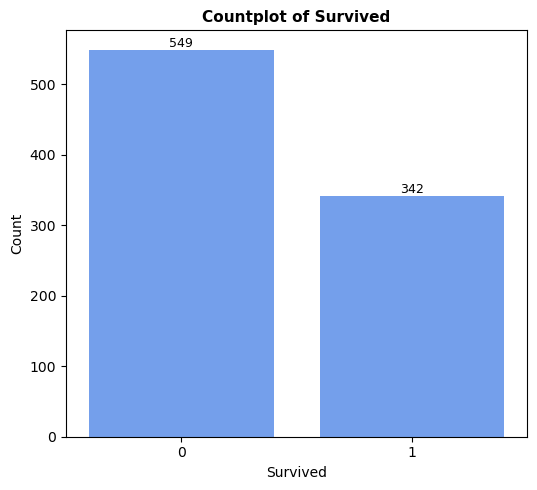

In [28]:
visualization.plot_countplots(train_df, ['Survived'])

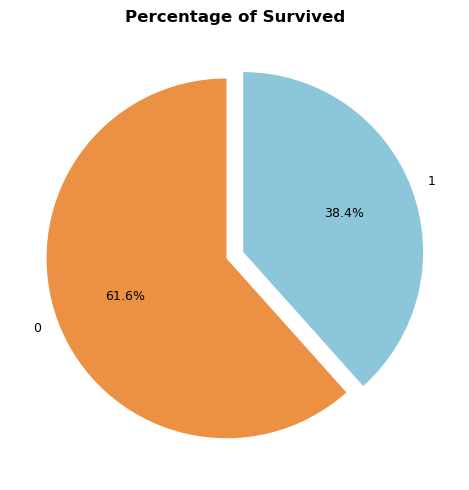

In [29]:
visualization.plot_piecharts(train_df, ['Survived'], colors=["#EC9044", '#8CC6DB'])

**Nhận xét**
- Tỷ lệ tử vong cao (61.6%) gấp 1.6 lần tỷ lệ sống sót (38.4%)
- Đây là dataset không cân bằng (imbalanced), cần lưu ý khi xây dựng mô hình
- Biểu đồ tròn cho thấy rõ sự chênh lệch lớn giữa hai nhóm
- Kết quả này phản ánh thực tế lịch sử: thảm họa Titanic là một trong những thảm kịch hàng hải lớn nhất

##### Count Plots

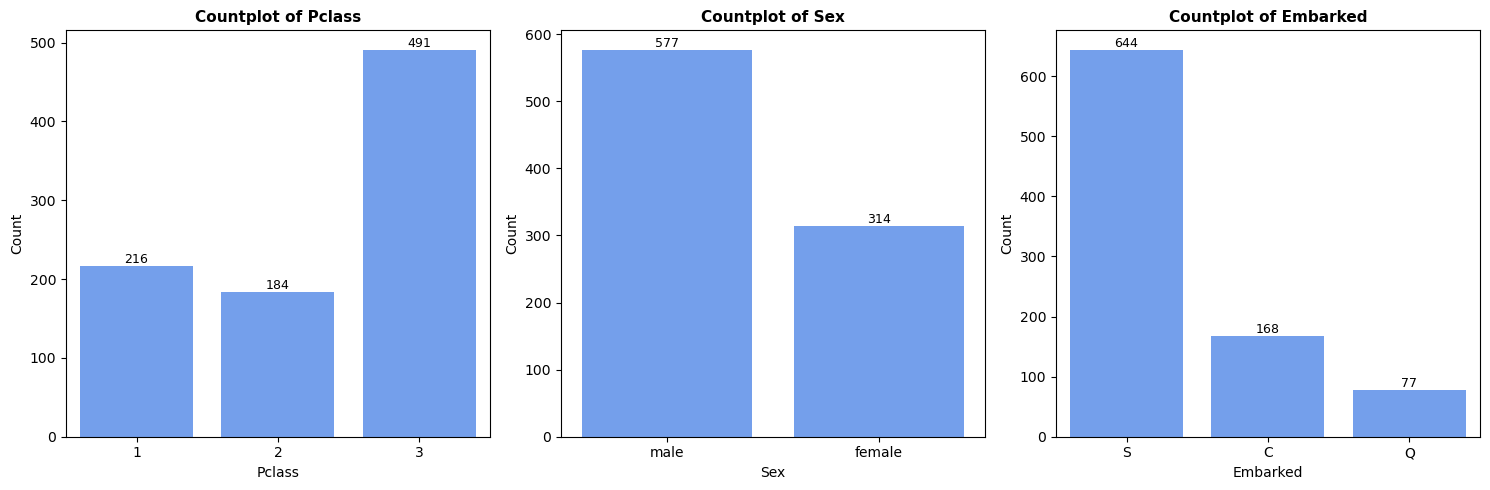

In [30]:
visualization.plot_countplots(train_df, ['Pclass', 'Sex', 'Embarked'])

**Nhận xét:**
- Pclass:
    - Hạng vé phản ánh địa vị xã hội/khả năng chi trả; hành khách hạng 1 chiếm phần nhỏ nhưng có tỷ lệ sống sót cao hơn.
    - Có sự khác biệt rõ rệt giữa các hạng: nên sử dụng Pclass làm feature mạnh cho mô hình.
    - Gợi ý: có thể tạo biến tương tác giữa Pclass và Fare hoặc Pclass và Sex để bắt tín hiệu tốt hơn.
- Sex:
    - Giới tính là biến dự đoán rất mạnh: phụ nữ có xác suất sống sót cao hơn nam giới nhiều.
    - Nguyên tắc lịch sử (phụ nữ và trẻ em trước) giải thích phần nào sự khác biệt này.
    - Gợi ý: giữ lại Sex; có thể mã hóa bằng one-hot hoặc binary (female=1).
- Embarked:
    - Dữ liệu Embarked có một vài giá trị thiếu; các cảng khác nhau có tỷ lệ sống sót khác nhau nhưng ảnh hưởng yếu hơn Sex và Pclass.
    - Cherbourg (C) có tỷ lệ sống sót cao hơn một chút; nhưng số lượng mẫu nhỏ hơn nên kết luận cần thận trọng.
    - Gợi ý: xử lý giá trị thiếu (mode hoặc riêng một category 'Unknown') trước khi sử dụng.

Khai báo các cột dữ liệu số

In [31]:
numerical_cols = ['Age', 'SibSp', 'Parch', 'Fare']

##### Box Plots

Age         Axes(0.125,0.53;0.352273x0.35)
SibSp    Axes(0.547727,0.53;0.352273x0.35)
Parch       Axes(0.125,0.11;0.352273x0.35)
Fare     Axes(0.547727,0.11;0.352273x0.35)
dtype: object

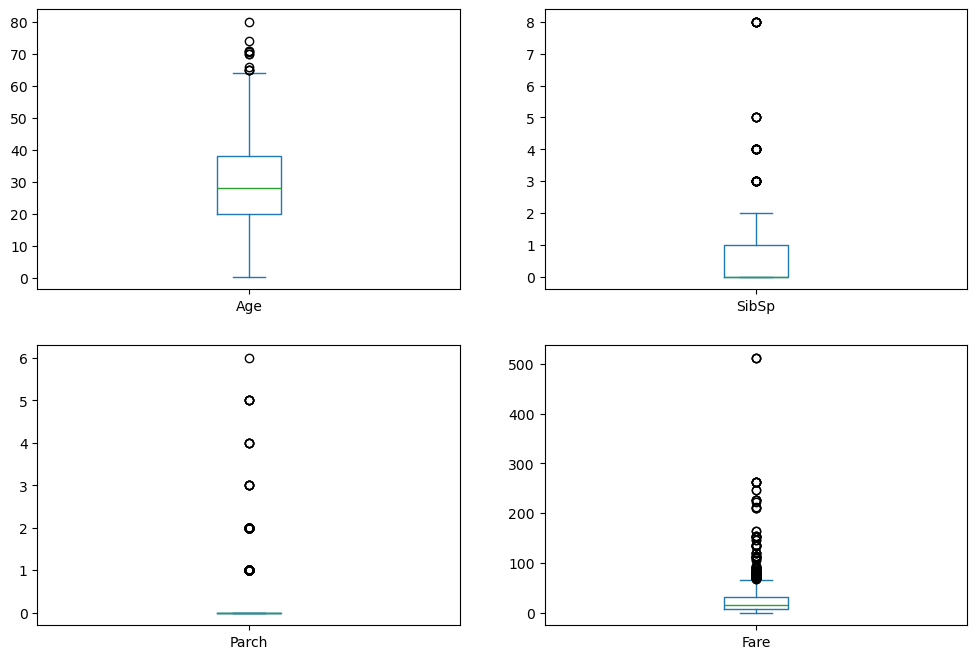

In [32]:
train_df[numerical_cols].plot(kind="box", subplots=True, layout=(2, 2), sharex=False, sharey=False, figsize=(12,8))

##### Histogram

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'SibSp'}>],
       [<Axes: title={'center': 'Parch'}>,
        <Axes: title={'center': 'Fare'}>]], dtype=object)

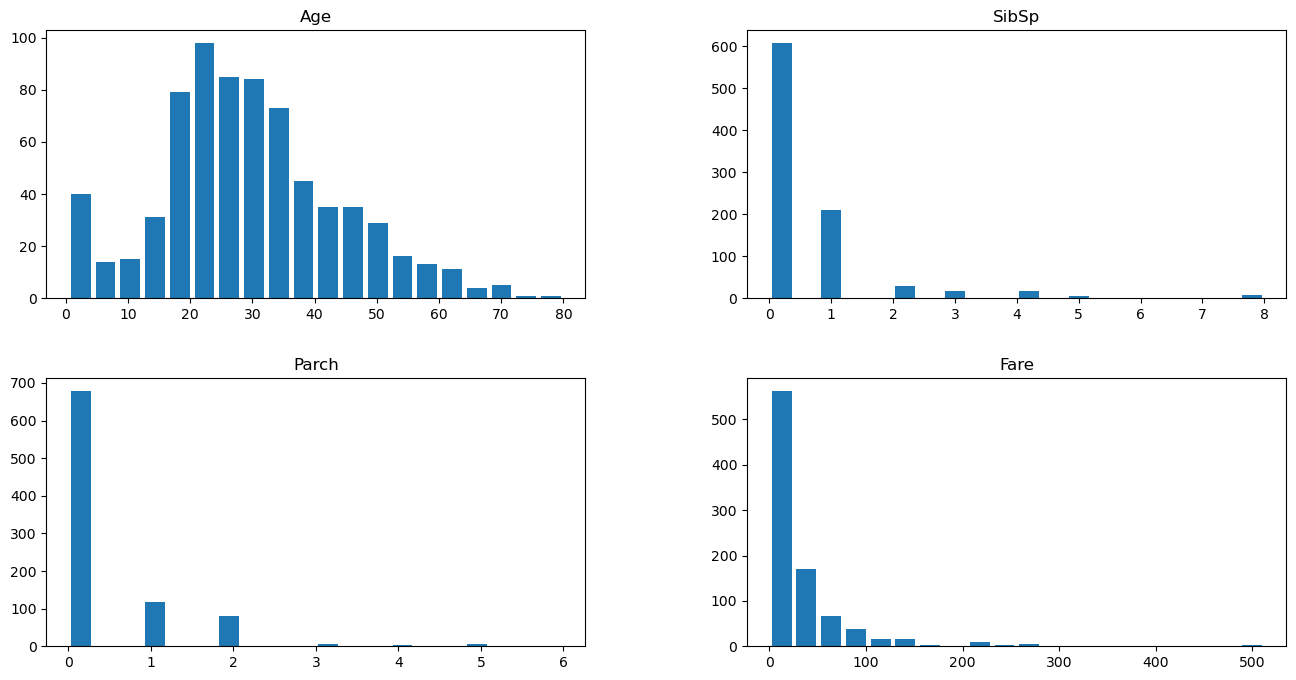

In [33]:
train_df[numerical_cols].hist(figsize=(16, 8), grid=False, rwidth=0.8, bins=20)

##### Density Plots

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

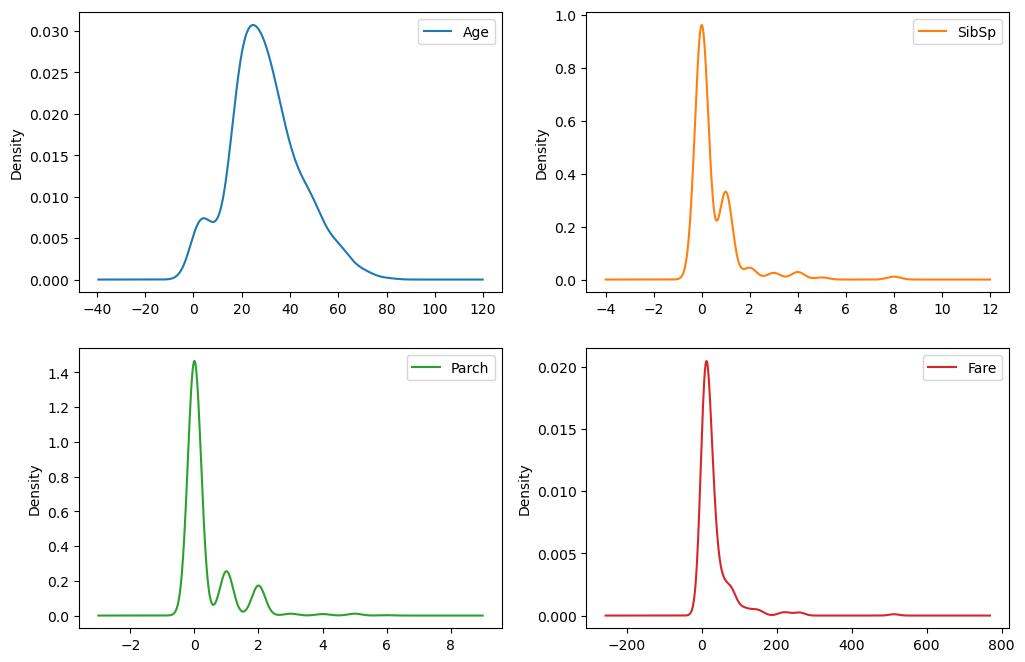

In [34]:
train_df[numerical_cols].plot(kind="density", subplots=True, layout=(2, 2), sharex=False, sharey=False, figsize=(12,8))

#### (2) **Hiển thị nhiều tính chất**

##### Count Plots

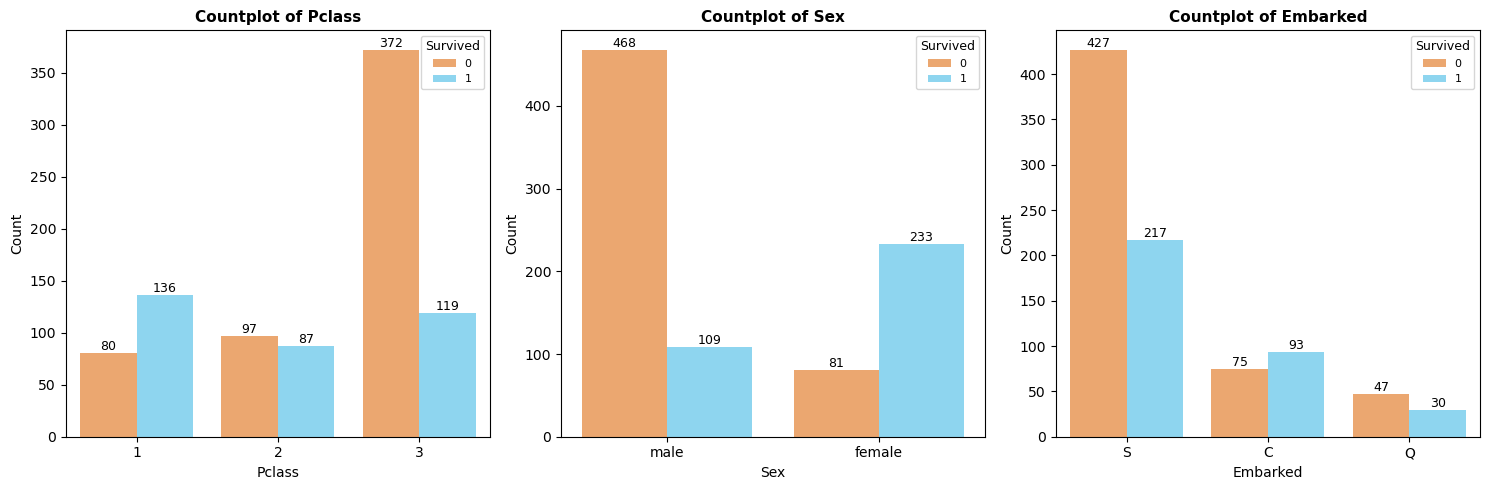

In [35]:
visualization.plot_countplots(train_df, ['Pclass', 'Sex', 'Embarked'], target='Survived', colors=["#FFA55C", "#7EDDFF"])

**Nhận xét:**

- **Hạng vé (Pclass):** Có mối quan hệ nghịch đảo rõ rệt - hạng càng cao (số càng nhỏ) thì tỷ lệ sống sót càng cao
  - Hạng 1: ~62% sống sót | Hạng 2: ~47% | Hạng 3: ~24%
  
- **Giới tính (Sex):** Tác động mạnh nhất - phụ nữ có tỷ lệ sống sót gấp 4 lần nam giới
  - Nữ: ~74% sống sót | Nam: ~19% - thể hiện nguyên tắc "phụ nữ và trẻ em trước"
  
- **Cảng khởi hành (Embarked):** Có sự khác biệt nhẹ, Cherbourg cao nhất (~55%), Southampton thấp nhất (~34%)
  - Có thể do thành phần hành khách khác nhau (hạng vé, thu nhập)

##### Distribution

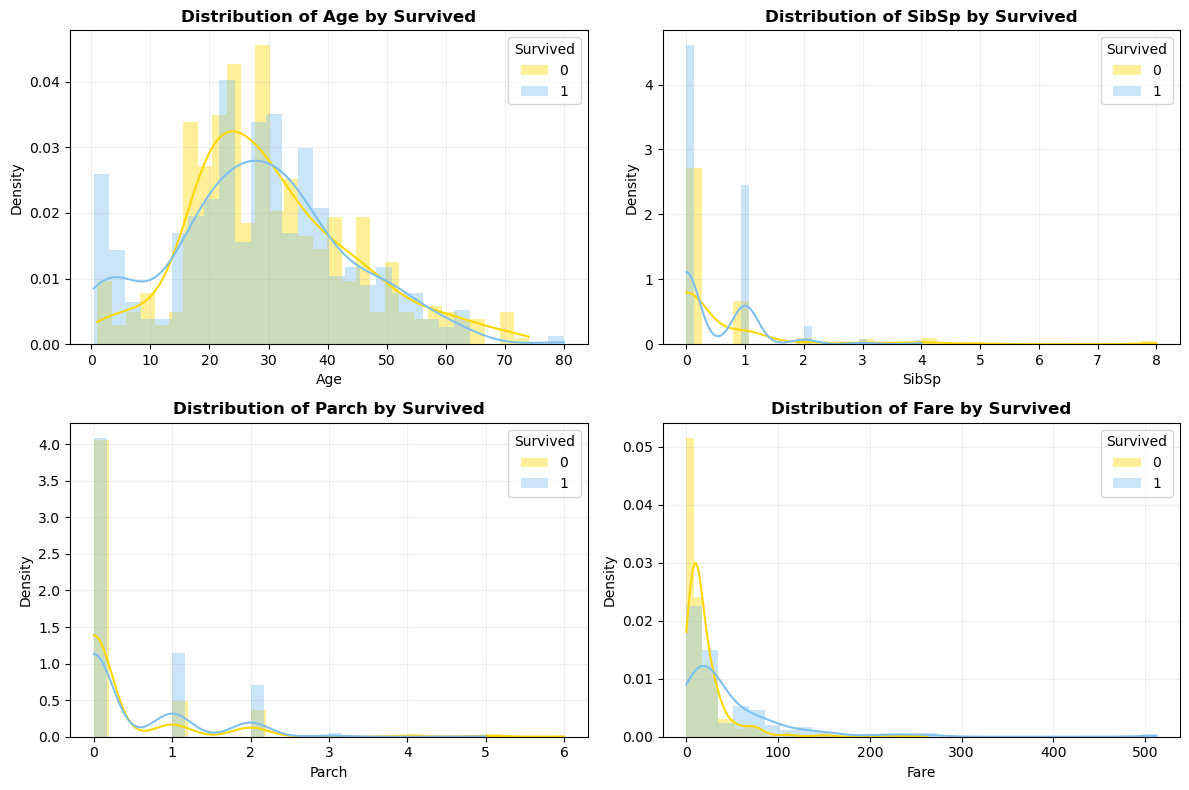

In [56]:
visualization.plot_distribution(train_df, numerical_cols, group_col='Survived')

##### Correlogram

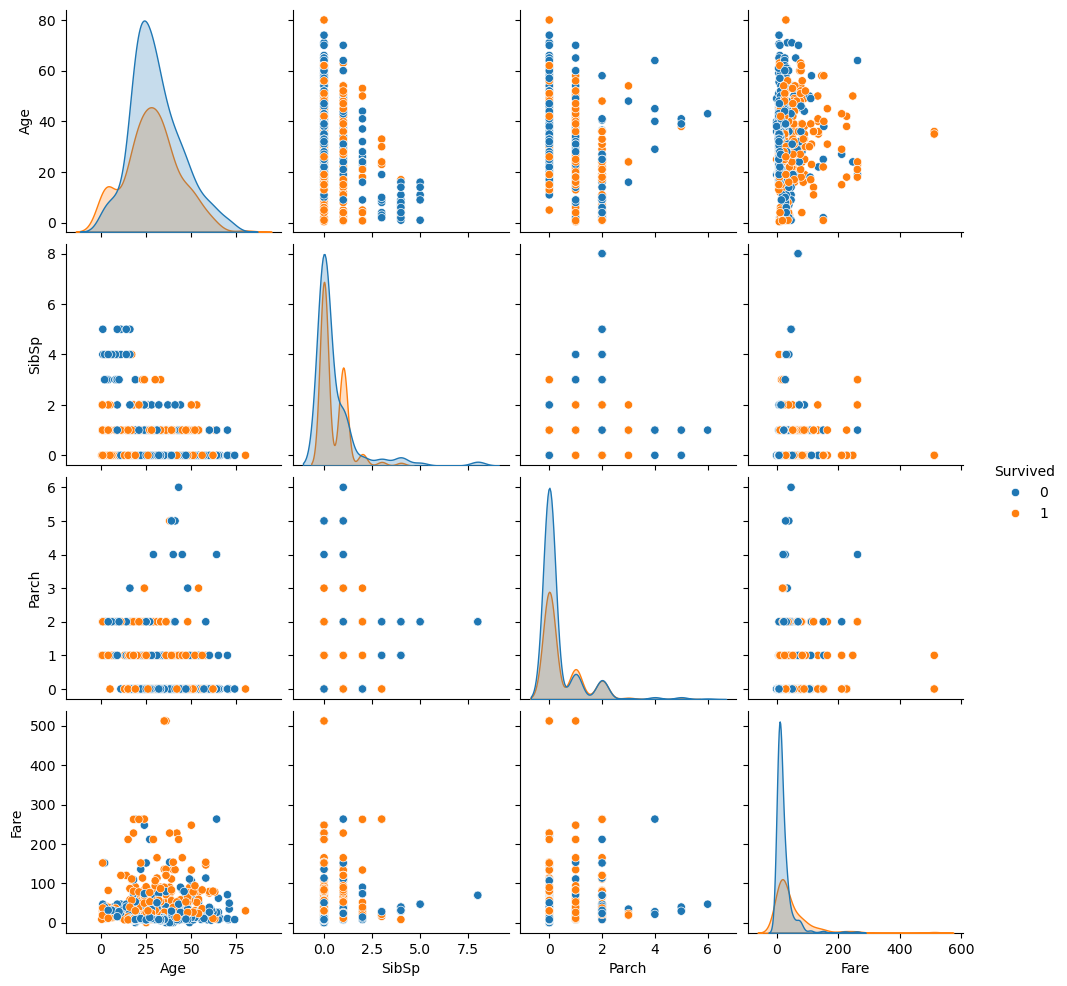

In [57]:
sns.pairplot(train_df[numerical_cols + ['Survived']], hue='Survived')

##### Heatmap

<Axes: >

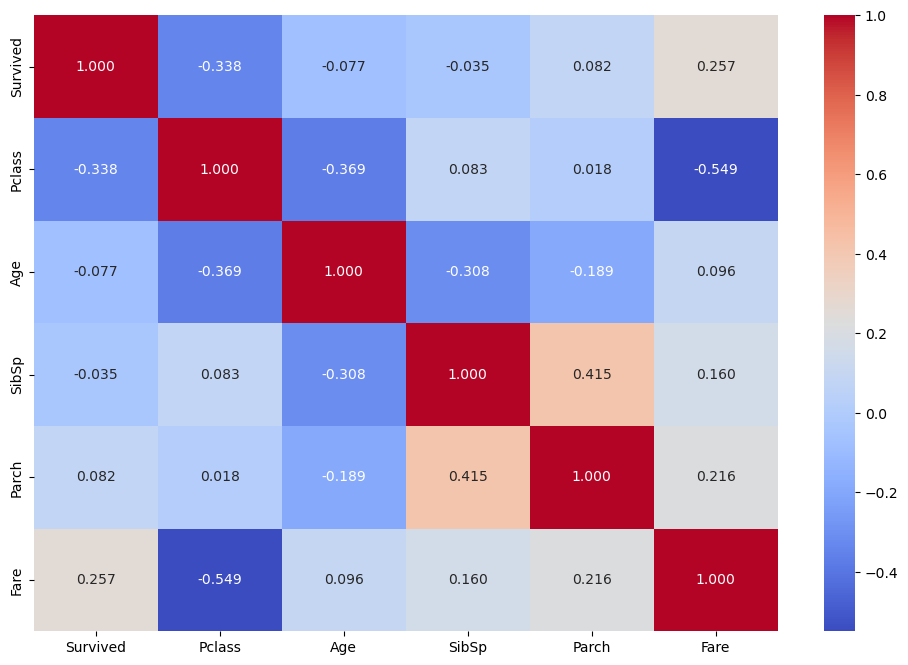

In [ ]:
fig = plt.figure(figsize=(12, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".3f")

# Kết thúc